## Sentiment Analysis

Possible questions:

__1. What sentiments are being conveyed between opposite-leaning news channels (CNN vs Fox News) when covering the anti-ICE protests based on each channel videos and comments?__

* This is the most natural question that comes up since I'm analyzing very polarizing media channels covering the same political issue, I'm analyzing and categorizing sentiments between how each channel covers it (through sentiment analysis of video titles and description) as well as how user comments' sentiments differ in each platform.

__2. What common sentiment characteristics are found in top viral/popular comments (with highest likes/replies) in each media outlet? Additionally, are sentiments in the 2 outlets equally share anger, or one has more negative reaction and the other has a more positive attitude?__

* We have info needed to answer this question using comments_likes and comment_reply_count variables. Also this is a very polarized and controversial topic where people would either agree (and get more likes in comment) or disagree (and lead to debates/more replies count) which would be interesting to see how these 2 metrics differ in key characteristics.

In [1]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

df = pd.read_csv("yt_comments.csv")
df.head()

,video_id,view_count,title,video_date,video_description,channel_name,comment_id,comment_text,comment_author_name,comment_author_channel_id,comment_date,comment_likes,comment_reply_count
0,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',2026-02-05T01:48:33Z,"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on ""The Arena"" to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",CNN,UgyNjKdvC4Xyk8zYl5h4AaABAg,They are regrouping.,@D_fen,UC2u_Dx5Tu64IViTSY1VInzA,2026-02-05T01:52:28Z,38,1
1,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',2026-02-05T01:48:33Z,"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on ""The Arena"" to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",CNN,UgxS4uoWMM_-Yt5vHI94AaABAg,"""If you don't call removing the 700 agents a de-escalation, what do you call it?""\n""A start.""",@dogrsqr,UC43hAYxNIxNfI-HUCxn7XUg,2026-02-05T02:11:20Z,23,2
2,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',2026-02-05T01:48:33Z,"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on ""The Arena"" to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",CNN,UgyzTnAwMsoPPfcHIwJ4AaABAg,"I agree, this is not de escalation when those 2000 will continue to follow their own rules and not the rule of law 😡",@laurasalazar5728,UC9_RKs37YKvnZww7nbLNmEA,2026-02-05T02:23:33Z,7,0
3,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',2026-02-05T01:48:33Z,"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on ""The Arena"" to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",CNN,UgzT2yeuJwtJMEd3-V54AaABAg,"No, they’re just flipping them out because they don’t wanna pay them for 30 straight days",@mafa7538,UCGsM-kCOMJ3tG4WZWWBxtpA,2026-02-05T01:59:32Z,17,2
4,u-E2O-aMdSY,14076,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',2026-02-05T01:48:33Z,"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on ""The Arena"" to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",CNN,Ugw2yQwJsfRDoOyqO5Z4AaABAg,"Instead of four agents to a car, there will be three.",@arnoldwillis7685,UCkK5iC-2xNF7oh3Vp3wRGiQ,2026-02-05T03:19:42Z,2,0


## Inspect & Data Cleaning

* Large complete dataset with 11,152 total comments, only 1 missing value in comment_text which can be dropped for analysis.
* Most variables are strings/texts, like IDs, titles, comments, dates, names. There are 3 numerical variables: view_count, comment_likes, and comment_reply_count.
* For view_count: highly right skewed (mean views at 338k while median only at 179k), video with max views has over 2M views while least viewed video has only 13k9 showing high variance in viewership/virality for the topic.
* Same for number of comment's likes and reply count: highly right skewed with only a few highly viral comments, 50% of comments have 54 likes and 3 replies or less.
* There are 372 unique videos across 2 channels, 11,152 mostly unique comments from 9875 unique commentors, indicating most are people and not a few spammers that left lots of comments.
* Titles of videos are clean but descriptions of fox news have repetitive boilerplate message that can be further cleaned.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11152 entries, 0 to 11151
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   video_id                   11152 non-null  object
 1   view_count                 11152 non-null  int64 
 2   title                      11152 non-null  object
 3   video_date                 11152 non-null  object
 4   video_description          11152 non-null  object
 5   channel_name               11152 non-null  object
 6   comment_id                 11152 non-null  object
 7   comment_text               11151 non-null  object
 8   comment_author_name        11152 non-null  object
 9   comment_author_channel_id  11152 non-null  object
 10  comment_date               11152 non-null  object
 11  comment_likes              11152 non-null  int64 
 12  comment_reply_count        11152 non-null  int64 
dtypes: int64(3), object(10)
memory usage: 1.1+ MB


In [3]:
df.describe().round(2)

,view_count,comment_likes,comment_reply_count
count,11152.00,11152.00,11152.00
mean,304959.89,174.12,16.02
std,338743.85,453.29,42.15
min,13914.00,0.00,0.00
25%,75888.00,15.00,0.00
50%,179369.00,54.00,3.00
75%,403825.00,159.00,14.00
max,2035804.00,10866.00,997.00


In [4]:
for col in df.columns:
    print(f'Variable: {col}, Unique: {len(df[col].unique())}')

Variable: video_id, Unique: 372
Variable: view_count, Unique: 372
Variable: title, Unique: 372
Variable: video_date, Unique: 372
Variable: video_description, Unique: 371
Variable: channel_name, Unique: 2
Variable: comment_id, Unique: 11152
Variable: comment_text, Unique: 11069
Variable: comment_author_name, Unique: 9875
Variable: comment_author_channel_id, Unique: 9875
Variable: comment_date, Unique: 11109
Variable: comment_likes, Unique: 1087
Variable: comment_reply_count, Unique: 273


In [5]:
df["title"].unique()[:10]

array(["Minneapolis Mayor says ICE agents leaving 'is not de-escalation'",
       "Renee Good's brother testifies on Capitol Hill",
       'Don Lemon defends his reporting of anti-ICE protest in church',
       'Thousands of Cyclists Ride to Honor Alex Pretti',
       'Italians protest ICE presence at Winter Olympics',
       "'I will not be silenced': Don Lemon speaks out after anti-ICE protest arrest",
       'Massive crowds turn out at anti-ICE protests across the US',
       'DOJ on why it’s investigating Alex Pretti’s killing but not Renee Good’s',
       'Students across America walkout to protest ICE',
       'Homan says ICE & CBP are working on Minneapolis ‘draw-down plan’'],
      dtype=object)

In [6]:
df["title"].unique()[-10:]

array(["NOT a 'peaceful protest': Congresswoman appears to shove ICE agent",
       "'DESPICABLE': Attorney calls out Dems for Newark ICE protest",
       'New bodycam footage shows Newark mayor during ICE protest #foxnews #news #politics #shorts #us #ice',
       'Protests break out for former Columbia student arrested by ICE',
       'ICE takes action against anti-Israel protester at Columbia',
       "'CROSSED A LINE': Homan sends fiery message to anti-ICE activists",
       "Anti-ICE resistance escalates as activists post agents' pictures",
       "Anti-ICE activists post photos of LA agents: 'Targets on their backs'",
       'Homan warns ICE raid protesters: ‘This is not a game’',
       "Tom Homan warns protesters impeding ICE raids 'could find themselves in handcuffs'"],
      dtype=object)

In [7]:
df["video_description"].unique()[-3:]

array(["DHS fired back at the 'pathetic' activists, vowing to hold them accountable for 'obstructing the law and justice.' The 'Fox & Friends' co-hosts weigh in. #FoxNews \n\nSubscribe to Fox News! https://bit.ly/2vBUvAS\nWatch more Fox News Video: http://video.foxnews.com\nWatch Fox News Channel Live: http://www.foxnewsgo.com/\n\nFOX News Channel (FNC) is a 24-hour all-encompassing news service delivering breaking news as well as political and business news. The number one network in cable, FNC has been the most-watched television news channel for 18 consecutive years. According to a 2020 Brand Keys Consumer Loyalty Engagement Index report, FOX News is the top brand in the country for morning and evening news coverage. A 2019 Suffolk University poll named FOX News as the most trusted source for television news or commentary, while a 2019 Brand Keys Emotion Engagement Analysis survey found that FOX News was the most trusted cable news brand. A 2017 Gallup/Knight Foundation survey also 

In [8]:
df["comment_text"].head()

0                                                                                                    They are regrouping.
1                           "If you don't call removing the 700 agents a de-escalation, what do you call it?"\n"A start."
2    I agree, this is not de escalation when those 2000 will continue to follow their own rules and not the rule of law 😡
3                               No, they’re just flipping them out because they don’t wanna pay them for 30 straight days
4                                                                   Instead of four agents to a car, there will be three.
Name: comment_text, dtype: object

**Common data cleaning:**

* Drop missing value identified in comment_text in 2a
* No duplicate comment so no need for extra cleaning of duplicates (all unique comment_id)
* Convert to datetime objects for easy processing

**Dealing with Youtube comments messy data**

* Since our tasks/research questions only involve sentiment analysis, noises like comments' URLs and mentions should be removed. Hashtags and emojis will be kept since they can contain sentiments info of movements like #embarrassment or #abolishICE, but I will remove the "#" symbol to analyze only the words contained in the tags.
* Remove double quotation (") since it adds no sentiment info, but keeping single quote (') since it's useful for negative words like "can't" or "don't".
* Remove self-promotional boilerplate message on Fox News videos' description using split(), offering no sentiment signals.
* Remove repetitive #foxnews (or #cnn) in video descriptions.
* Clean up trailing whitespaces and line breaks "\n"
* Replace and standardizing apostrophes (straight, curly, etc. into straight apostrophes only).

In [9]:
# Common data cleaning
df_cleaned = df.dropna(subset=['comment_text']).copy()
df_cleaned['video_date'] = pd.to_datetime(df_cleaned['video_date'])
df_cleaned['comment_date'] = pd.to_datetime(df_cleaned['comment_date'])

In [10]:
import re
# Messy texts cleaning (built on textcleaner function in lab_8_nltk)
def text_cleaner(row):
    #remove urls
    row  = re.sub(r'http[s]\S+', '', row)
    #remove mentions
    row = re.sub(r"(?<![@\w])@(\w{1,25})", '', row)
    #replace different curly apostrophes/quotes to straight apostrophes
    row = re.sub(r'[’‘´]', "'", row)
    #remove hashtag, quotation marks and other symbols specified
    row = re.sub(r'[#"“”]|(\'\')', '', row)
    #remove trailing white spaces
    row = row.strip()
    #remove random white spaces into normal single space
    row = re.sub(r'\s+', ' ', row)
    return row

def description_cleaner(row):
    #remove repetitive #foxnews
    row = re.sub(r'(?i)#foxnews\b', '', row)
    #remove repetitive #cnn
    row = re.sub(r'(?i)#cnn\b', '', row)
    #remove repetitive #news
    row = re.sub(r'(?i)#news\b', '', row)
    #remove self-promotional boilerplate message using split()
    row = row.split("Subscribe to Fox News")[0]

    #pass rest of description through text_cleaner
    return text_cleaner(row)

In [11]:
df_cleaned['comment_text'] = df_cleaned['comment_text'].apply(text_cleaner)
df_cleaned['video_description'] = df_cleaned['video_description'].apply(description_cleaner)
df_cleaned['title'] = df_cleaned['title'].apply(description_cleaner)

In [15]:
df_cleaned["comment_text"].head()

0                                                                                                    They are regrouping.
1                                If you don't call removing the 700 agents a de-escalation, what do you call it? A start.
2    I agree, this is not de escalation when those 2000 will continue to follow their own rules and not the rule of law 😡
3                               No, they're just flipping them out because they don't wanna pay them for 30 straight days
4                                                                   Instead of four agents to a car, there will be three.
Name: comment_text, dtype: object

In [49]:
df_cleaned.to_csv("cleaned_yt_comments.csv", index=False)

### Tokenize
Experimenting with 3 different types of tokenizers.

Tokenizing the 3 main text columns of dataset: "title", "video_description", and "comment_text"

In [16]:
!pip install nltk

  Using cached nltk-3.9.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached regex-2026.2.28-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
Using cached nltk-3.9.3-py3-none-any.whl (1.5 MB)
Using cached regex-2026.2.28-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (802 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [nltk]


In [17]:
text_df = df_cleaned[["channel_name","title", "video_description", "comment_date", "comment_text"]].copy()
text_df.head()

,channel_name,title,video_description,comment_date,comment_text
0,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026-02-05 01:52:28+00:00,They are regrouping.
1,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026-02-05 02:11:20+00:00,"If you don't call removing the 700 agents a de-escalation, what do you call it? A start."
2,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026-02-05 02:23:33+00:00,"I agree, this is not de escalation when those 2000 will continue to follow their own rules and not the rule of law 😡"
3,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026-02-05 01:59:32+00:00,"No, they're just flipping them out because they don't wanna pay them for 30 straight days"
4,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026-02-05 03:19:42+00:00,"Instead of four agents to a car, there will be three."


In [18]:
import nltk
from nltk.tokenize import word_tokenize, WhitespaceTokenizer, WordPunctTokenizer, TweetTokenizer

ws = WhitespaceTokenizer()
wp = WordPunctTokenizer()
tw = TweetTokenizer()

for col in text_df.columns.difference(['channel_name', 'comment_date']):
    text_df[f"w_{col}"] = text_df[col].apply(word_tokenize)
    text_df[f"ws_{col}"] = text_df[col].apply(ws.tokenize)
    text_df[f"wp_{col}"] = text_df[col].apply(wp.tokenize)
    text_df[f"tw_{col}"] = text_df[col].apply(tw.tokenize)

In [19]:
text_df.head(3)

,channel_name,title,video_description,comment_date,comment_text,w_comment_text,ws_comment_text,wp_comment_text,tw_comment_text,w_title,ws_title,wp_title,tw_title,w_video_description,ws_video_description,wp_video_description,tw_video_description
0,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026-02-05 01:52:28+00:00,They are regrouping.,"[They, are, regrouping, .]","[They, are, regrouping.]","[They, are, regrouping, .]","[They, are, regrouping, .]","[Minneapolis, Mayor, says, ICE, agents, leaving, 'is, not, de-escalation, ']","[Minneapolis, Mayor, says, ICE, agents, leaving, 'is, not, de-escalation']","[Minneapolis, Mayor, says, ICE, agents, leaving, ', is, not, de, -, escalation, ']","[Minneapolis, Mayor, says, ICE, agents, leaving, ', is, not, de-escalation, ']","[CNN, 's, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge, ,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota, .]","[CNN's, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota.]","[CNN, ', s, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge, ,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota, .]","[CNN's, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge, ,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota, .]"
1,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026-02-05 02:11:20+00:00,"If you don't call removing the 700 agents a de-escalation, what do you call it? A start.","[If, you, do, n't, call, removing, the, 700, agents, a, de-escalation, ,, what, do, you, call, it, ?, A, start, .]","[If, you, don't, call, removing, the, 700, agents, a, de-escalation,, what, do, you, call, it?, A, start.]","[If, you, don, ', t, call, removing, the, 700, agents, a, de, -, escalation, ,, what, do, you, call, it, ?, A, start, .]","[If, you, don't, call, removing, the, 700, agents, a, de-escalation, ,, what, do, you, call, it, ?, A, start, .]","[Minneapolis, Mayor, says, ICE, agents, leaving, 'is, not, de-escalation, ']","[Minneapolis, Mayor, says, ICE, agents, leaving, 'is, not, de-escalation']","[Minneapolis, Mayor, says, ICE, agents, leaving, ', is, not, de, -, escalation, ']","[Minneapolis, Mayor, says, ICE, agents, leaving, ', is, not, de-escalation, ']","[CNN, 's, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge, ,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota, .]","[CNN's, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota.]","[CNN, ', s, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge, ,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota, .]","[CNN's, Kasie, Hunt, spoke, with, Minneapolis, Mayor, Jacob, Frey, on, The, Arena, to, discuss, Operation, Metro, Surge, ,, the, ICE, and, Customs, and, Border, Protection, operation, in, Minnesota, .]"
2,CNN,Minneapolis Mayor says ICE agents leaving 'is not de-escalation',"CNN's Kasie Hunt spoke with Minneapolis Mayor Jacob Frey on The Arena to discuss Operation Metro Surge, the ICE and Customs and Border Protection operation in Minnesota.",2026

### Best tokenizer so far: TweetTokenizer

1. word_tokenize incorrectly split casual and short form expressions like "don't" and "wanna" into "do"/"n't" and "wan"/"na".
2. WhitespaceTokenizer simply splits texts based on any white space but kept trailing punctuations like commas with the word (e.g. row 3 comment token "agree,") vs TweetTokenizer splitting commas separately from word, which I prefer.
3. WordPunctTokenizer splits "don't" into "don", "'", and "'t" which is also weird and lose meaning of original term.
4. Only TweetTokenizer recognizes shortened words like "don't", keeping whole words together ("de-escalation") without added punctuations like commas and trailing so we can process whole words for sentiments and word count easily/correctly.

## Analyze Data for Sentiment


### Experimenting with three different ways of conducting sentiment analysis.

**Summary of what each method's scores mean:**
1. Opinion Lexicon: Uses sum of number of negative and positive words.
2. VADER: Uses normalized, weighted compound score, from -1 (most extreme negative) to +1 (most extreme positive).
3. TextBlob: Uses polarity score also ranging from -1 (most negative) to +1 (most positive).

In most plain-text (no emojis) neutral cases, the 3 models agrees and all give score of 0. For cases with emojis, it appears VADER catches this nuances the best. Like in row 2, VADER adjusts the score to be lower than textBlob even though it catches positive words like "agree", same for row 9 it assigns a very strong positive score even though there is not a lot of positive words matched in comment text.

TextBlob also does worse for negative cases compared to the other 2 methods, like giving positive scores for row 8 and 5. Opinion lexicon is the most conservative and give less granular score since it's only matching number of positive and negative in a limited dictionary/database. For newer slang or informal words, it was not able to match a lot and give mostly neutral (0) scores.

In [20]:
from nltk.corpus import opinion_lexicon

# nltk.download('opinion_lexicon') #this download needs to happen for the very first time
nltk.download('opinion_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/jovyan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
# Get text lists from TweetTokenizer results
comment_text_tokens = text_df[["channel_name","comment_date","comment_text","tw_comment_text"]].copy()

In [22]:
pos_words = set(opinion_lexicon.positive())
neg_words = set(opinion_lexicon.negative())

def opinion_lexicon_score(tokens):
    sent_sum = 0
    for token in tokens:
        token = token.lower()
        if token in pos_words:
            sent_sum += 1
        elif token in neg_words:
            sent_sum -= 1
    return sent_sum

# A simple test by counting frequency of pos and neg words appearing
# + for overall more positive, - for overall more negative sentiments

comment_text_tokens['opinion_lexicon_score'] = comment_text_tokens["tw_comment_text"].apply(opinion_lexicon_score)

In [23]:
# install vader
!pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [24]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    score = analyzer.polarity_scores(text)['compound']
    return score

comment_text_tokens['vader_score'] = comment_text_tokens['comment_text'].apply(vader_score)

In [25]:
!pip install TextBlob

  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
Using cached textblob-0.19.0-py3-none-any.whl (624 kB)


In [26]:
from textblob import TextBlob

def textblob_score(text):
    score = TextBlob(text).polarity
    return score

comment_text_tokens['textblob_score'] = comment_text_tokens['comment_text'].apply(textblob_score)

In [27]:
# Results comparison table
comment_text_tokens.head(10)

,channel_name,comment_date,comment_text,tw_comment_text,opinion_lexicon_score,vader_score,textblob_score
0,CNN,2026-02-05 01:52:28+00:00,They are regrouping.,"[They, are, regrouping, .]",0,0.0000,0.000000
1,CNN,2026-02-05 02:11:20+00:00,"If you don't call removing the 700 agents a de-escalation, what do you call it? A start.","[If, you, don't, call, removing, the, 700, agents, a, de-escalation, ,, what, do, you, call, it, ?, A, start, .]",0,0.0000,0.000000
2,CNN,2026-02-05 02:23:33+00:00,"I agree, this is not de escalation when those 2000 will continue to follow their own rules and not the rule of law 😡","[I, agree, ,, this, is, not, de, escalation, when, those, 2000, will, continue, to, follow, their, own, rules, and, not, the, rule, of, law, 😡]",0,0.3612,0.600000
3,CNN,2026-02-05 01:59:32+00:00,"No, they're just flipping them out because they don't wanna pay them for 30 straight days","[No, ,, they're, just, flipping, them, out, because, they, don't, wanna, pay, them, for, 30, straight, days]",0,0.2951,0.200000
4,CNN,2026-02-05 03:19:42+00:00,"Instead of four agents to a car, there will be three.","[Instead, of, four, agents, to, a, car, ,, there, will, be, three, .]",0,0.0000,0.000000
5,CNN,2026-02-05 01:53:03+00:00,Minnesota has become an occupied state by masked fascists. The whole city of Minneapolis is basically being held hostage.,"[Minnesota, has, become, an, occupied, state, by, masked, fascists, ., The, whole, city, of, Minneapolis, is, basically, being, held, hostage, .]",-1,-0.2023,0.200000
6,CNN,2026-02-05 02:24:09+00:00,They're not getting paid or that sign on bonus 😂😂😂,"[They're, not, getting, paid, or, that, sign, on, bonus, 😂, 😂, 😂]",1,0.9042,0.000000
7,CNN,2026-02-05 02:03:29+00:00,They probably quit because they weren't getting paid!!,"[They, probably, quit, because, they, weren't, getting, paid, !, !]",0,0.0000,0.000000
8,CNN,2026-02-05 02:16:17+00:00,They are distracting us. Making us think they can compromise but we know there are too many of those racists in uniform out there still. Maybe those 700 are just being relocated to another state. Same 💩 different place,"[They, are, distracting, us, ., Making, us, think, they, can, compromise, but, we, know, there, are, too, many, of, those, racists, in, uniform, out, there, still, ., Maybe, those, 700, are, just, being, relocated, to, another, state, ., Same, 💩, different, place]",-2,-0.7469,0.166667
9,CNN,2026-02-05 02:57:43+00:00,This is a guy I would love to lead me lol,"[This, is, a, guy, I, would, love, to, lead, me, lol]",2,0.7906,0.650000


### Quantitatively comparing methods

To compare what proportion of comments match/not match between each pair, I will need to convert them to a consistent value for matching (like scale of 3 values of negative (-1), neutral (0), and positive(1)) since their original scores are not on the same scale. 

Result of percentage of matched sentiment categories between each pair of methods:

* Vader and lexicon agrees the most (61% of the time). This is surprising and probably indicates our dataset of comments have a lot of explicit sentiment words that without considering in more granular scale and just focus on the bigger 3 categories of "negative", "positive", and "neutral, both the simple lexicon and more advanced VADER method can spot the right overall sentiment.
* Textblob scores lowest with both lexicon and VADER (agrees only ~55% and 50% of the time respectively). This might be because textblob relies on a more formal structure of sentence and adjectives that doesn't work very well on tweets/social media comments.


In [28]:
# Categorize sentiment categories for textblob and VADER since they're the same range -1 to 1
def sentiment_categorize(score):
    if score >= 0.05:
        return 1
    elif score <= -0.05:
        return -1
    else:
        return 0

# Categorize opinion lexicon scores into sentiment categories
def lexicon_sent_categorize(score):
    if score > 0:
        return 1
    elif score < 0:
        return -1
    else:
        return score

comment_text_tokens["lexicon_cat"] = comment_text_tokens["opinion_lexicon_score"].apply(lexicon_sent_categorize)
comment_text_tokens["vader_cat"] = comment_text_tokens["vader_score"].apply(sentiment_categorize)
comment_text_tokens["textblob_cat"] = comment_text_tokens["textblob_score"].apply(sentiment_categorize)

In [29]:
def percentage_match(df, col1, col2):
    return (df[col1] == df[col2]).mean() * 100


comparison_table = {"method_pair": ["vader_textblob", "vader_lexicon", "textblob_lexicon"],
                    "percentage_match": [percentage_match(comment_text_tokens, 'vader_cat', 'textblob_cat'),
                                         percentage_match(comment_text_tokens, 'vader_cat', 'lexicon_cat'),
                                         percentage_match(comment_text_tokens, 'textblob_cat', 'lexicon_cat')
                                        ]
                    }

comparison_table = pd.DataFrame(comparison_table)
print(comparison_table)

        method_pair  percentage_match
0    vader_textblob         50.264550
1     vader_lexicon         61.438436
2  textblob_lexicon         55.080262


### 3c) Qualitative + Quantitative comparison: 

Method: randomly pick 40 comments to score sentiments manually myself. Then compare with two other sentiment analysis methods (VADER and Opinion Lexicon) on identifying the sentiments of these 40 tweets.

My result below shows that VADER did significantly better than Opinion Lexicon (60% vs 42.5%). This makes sense because I expect VADER to have more context and modern, advanced dictionary compared to Lexicon, which relies on very rigid and brute-force way of matching and counting each word in sentence to a pre-labeled lexicon dictionary that doesn't capture new informal slangs in written texts and comments on social media platform.

In [30]:
sample_df = comment_text_tokens[
    ["comment_text", "tw_comment_text", "vader_cat", "lexicon_cat", "textblob_cat"]
    ].sample(n=40, random_state=8).copy()

In [31]:
sample_df = sample_df.reset_index(drop=True)

In [32]:
hand_labels = [-1, 1, -1, -1, -1, -1, -1, -1, -1, -1, 
               0, -1, -1, -1, -1, -1, -1, -1, -1, -1, 
               -1, -1, 0, -1, -1, -1, -1, -1, -1, -1, 
               -1, -1, 0, 1, -1, -1, -1, -1, -1, -1]
sample_df['hand_label'] = hand_labels

In [33]:
sample_df.head()

,comment_text,tw_comment_text,vader_cat,lexicon_cat,textblob_cat,hand_label
0,N0 WORLD CUP 2026 IN LA CA 😊,"[N0, WORLD, CUP, 2026, IN, LA, CA, 😊]",1,0,0,-1
1,Thank You - Tom - For Doing YOUR Job...Stay Safe...Stay Strong...,"[Thank, You, -, Tom, -, For, Doing, YOUR, Job, ..., Stay, Safe, ..., Stay, Strong, ...]",1,1,1,1
2,What the hell is wrong with people?,"[What, the, hell, is, wrong, with, people, ?]",-1,-1,-1,-1
3,Everyone is being tracked in their vehicle all of the time. Palantir.,"[Everyone, is, being, tracked, in, their, vehicle, all, of, the, time, ., Palantir, .]",0,0,0,-1
4,ICEneeds to start getting these clowns in jail,"[ICEneeds, to, start, getting, these, clowns, in, jail]",0,0,-1,-1


In [34]:
vader_accuracy = percentage_match(sample_df, 'vader_cat', 'hand_label')
vader_accuracy

np.float64(60.0)

In [35]:
lexicon_accuracy = percentage_match(sample_df, 'lexicon_cat', 'hand_label')
lexicon_accuracy

np.float64(42.5)

## Data over time

How does the polarity (sentiment) of the corpus change over time?


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_time_polarity(df, channel_name):
    df["day"] = df["comment_date"].dt.date
    df = df.groupby("day")[['vader_score', 'textblob_score']].mean().reset_index()
    
    sns.lineplot(data=df, x='day', y='vader_score', label='VADER', color='blue', linewidth=2)
    sns.lineplot(data=df, x='day', y='textblob_score', label='TextBlob', color='orange', linewidth=2)

    plt.title(f'Sentiment Polarity of {channel_name} Youtube Comments Over Time')
    plt.xlabel('Date')
    plt.ylabel('Mean sentiment score')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

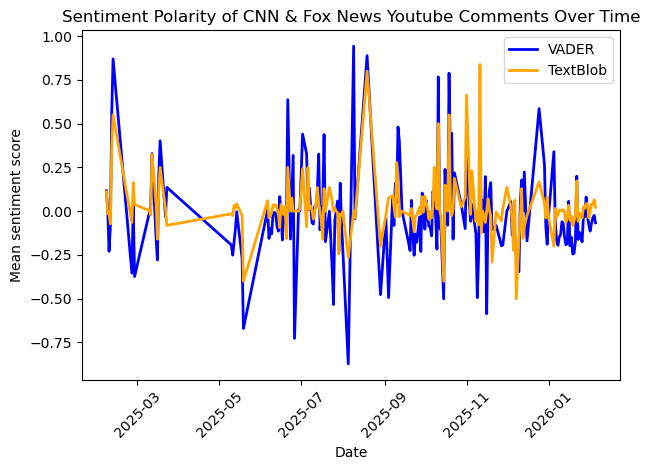

In [45]:
# Plot of entire dataset (all CNN and Fox comments)
time_df = comment_text_tokens[["comment_date", "vader_score", "textblob_score"]].copy()

plot_time_polarity(time_df, "CNN & Fox News")

* As an overall trend, our superimposed plots of Youtube comments' sentiment over time on the topic from the 2 methods align pretty well with each other.
* There is only one period where they have extreme opposite average scores (during late November 2025) where TextBlob reveals highly positive score (about 0.75) while VADER shows peaks of negative scores (about -0.5)
* VADER scores are more polarized (fluctuate with high magnitudes) compared to TextBlob which looks more concentrated around neutral (score 0) line.
* A prominent decline from positive to negative sentiment during April-May 2025. A quick Google search gives me an idea that this is during the May Day protest for labor rights and immigrant communities so ICE movement sentiments were probably also intensified. Though this can also be a lack of news videos reporting on ICE protests from both CNN and Fox News during that month, probably focusing on other news issues around the same time like trade wars and tarriffs.

A note: Our full dataset contains majority of Fox News videos/comments (75% of data points) identified as relevant to anti-ICE movement, so our mean score might be skewed towards sentiments of Fox News commentors. Out of curiosity, I also plotted how the analyzers perform differently on CNN vs Fox News comments and found:

* TextBlob fails to assign sentiments for CNN comments (most scores are neutral) but works very well for Fox News data (highly correlated with VADER for FOX comments), which makes sense since Textblob relies on POS tagging and works better for longer, formal texts while VADER is optimized for short social media forms involving slangs and emojis.

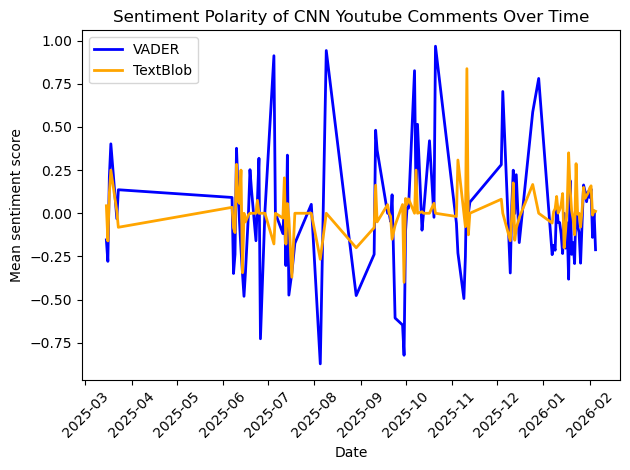

In [46]:
cnn_plot_df = comment_text_tokens[comment_text_tokens['channel_name'] == 'CNN'].copy()

plot_time_polarity(cnn_plot_df, "CNN")

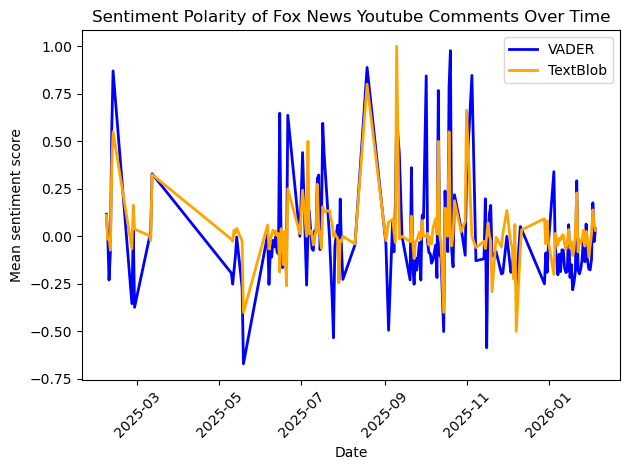

In [47]:
fox_plot_df = comment_text_tokens[comment_text_tokens['channel_name'] == 'Fox News'].copy()
plot_time_polarity(fox_plot_df, "Fox News")